In [ ]:
import marimo as mo

# ДЗ №1 СУНЦ МГУ - Numpy practice

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.

### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

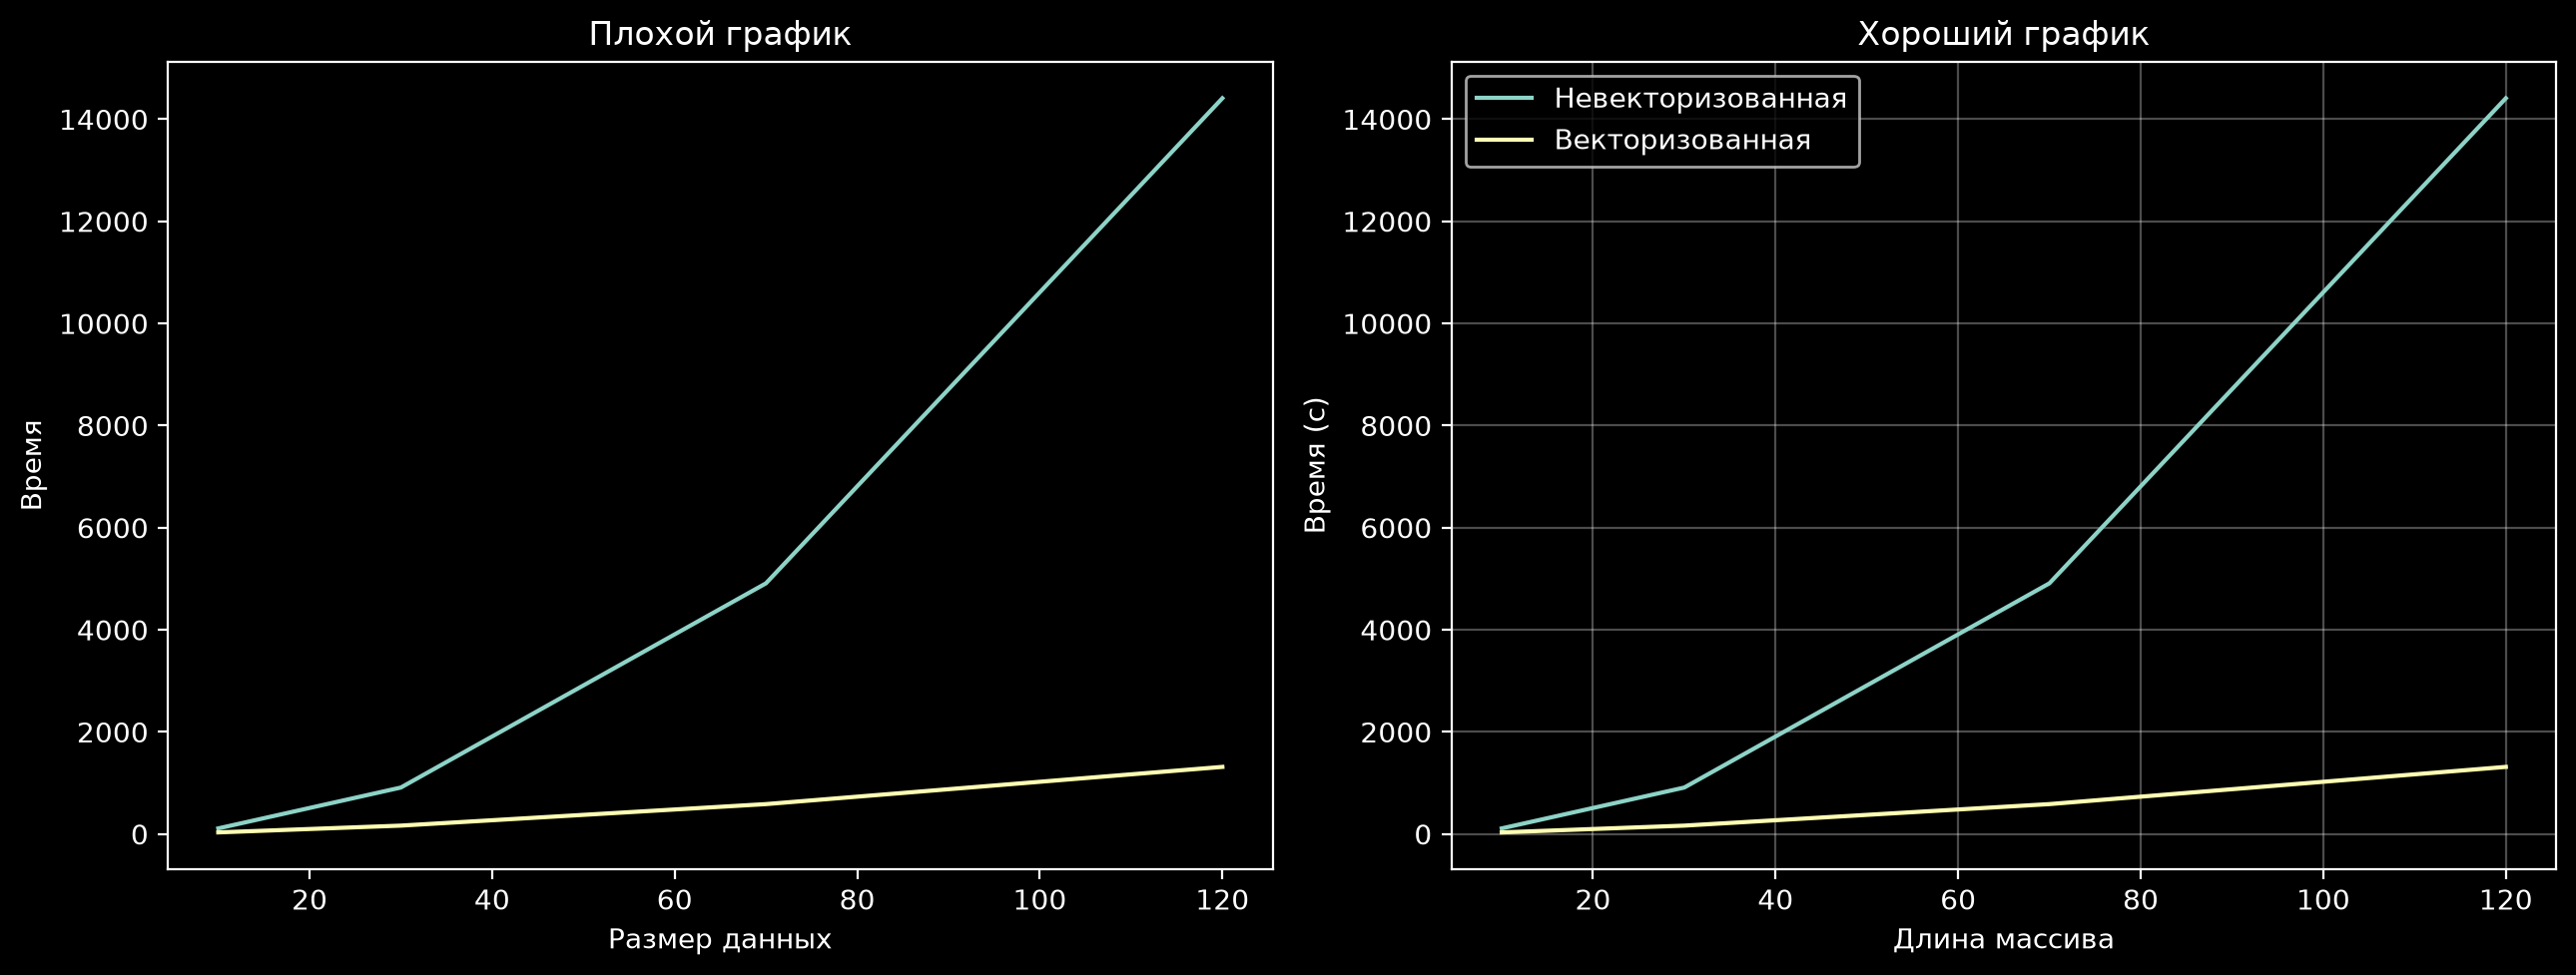

In [ ]:
from importlib import reload
import time
import random

import matplotlib.pyplot as plt
import numpy as np

import functions
import functions_vectorized

# '%matplotlib inline' command supported automatically in marimo


def reload_solution_modules():
    """Reload the two local solution modules after their files change."""
    reload(functions)
    reload(functions_vectorized)


data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size**2 + 10
time_vectorized = data_size**1.5

figure, (axis_bad, axis_good) = plt.subplots(1, 2, figsize=(13, 5))

axis_bad.plot(data_size, time_non_vectorized)
axis_bad.plot(data_size, time_vectorized)
axis_bad.set_title("Плохой график")
axis_bad.set_xlabel("Размер данных")
axis_bad.set_ylabel("Время")

axis_good.plot(data_size, time_non_vectorized, label="Невекторизованная")
axis_good.plot(data_size, time_vectorized, label="Векторизованная")
axis_good.set_title("Хороший график")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()

* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

/home/gemefoll/ml_school/task_numpy/functions.py:7: RuntimeWarning: overflow encountered in scalar multiply
  prod *= 1 if x[i][i] == 0 else x[i][i]


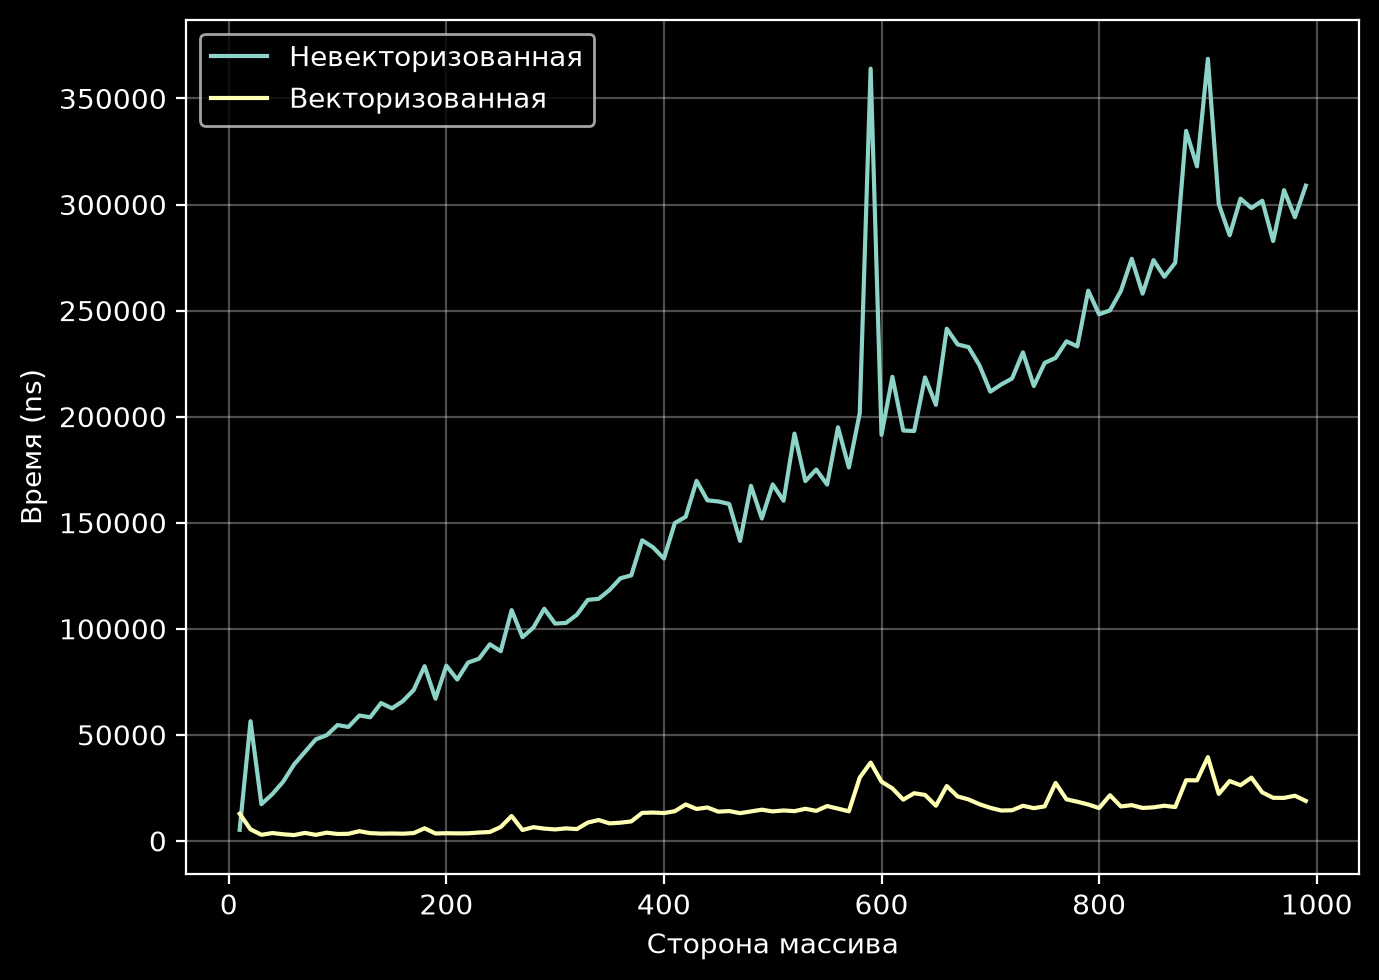

In [ ]:
reload_solution_modules()

def task1plot():
    data_size = np.arange(10, 1000, 10)
    tnv, tv = [], []
    for sz in data_size:
        sh = np.reshape(np.arange((sz + 1) * sz), (sz + 1, sz))
        random.shuffle(sh)
        lsh = sh.tolist()
        time_non_vectorized = time.perf_counter_ns()
        res11 = functions.prod_non_zero_diag(sh)
        res12 = functions.prod_non_zero_diag(sh)
        tnv.append((time.perf_counter_ns() - time_non_vectorized) / 2)
        time_vectorized = time.perf_counter_ns()
        res21 = functions_vectorized.prod_non_zero_diag(sh)
        res22 = functions_vectorized.prod_non_zero_diag(sh)
        tv.append((time.perf_counter_ns() - time_vectorized) / 2)
        assert res11 == res21 and res12 == res22

    figure, axis_good = plt.subplots(1, 1, figsize=(7, 5))

    axis_good.plot(data_size, tnv, label="Невекторизованная")
    axis_good.plot(data_size, tv, label="Векторизованная")
    axis_good.set_xlabel("Сторона массива")
    axis_good.set_ylabel("Время (ns)")
    axis_good.grid(True, alpha=0.3)
    axis_good.legend()

    figure.tight_layout()
    plt.show()

task1plot()

* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.

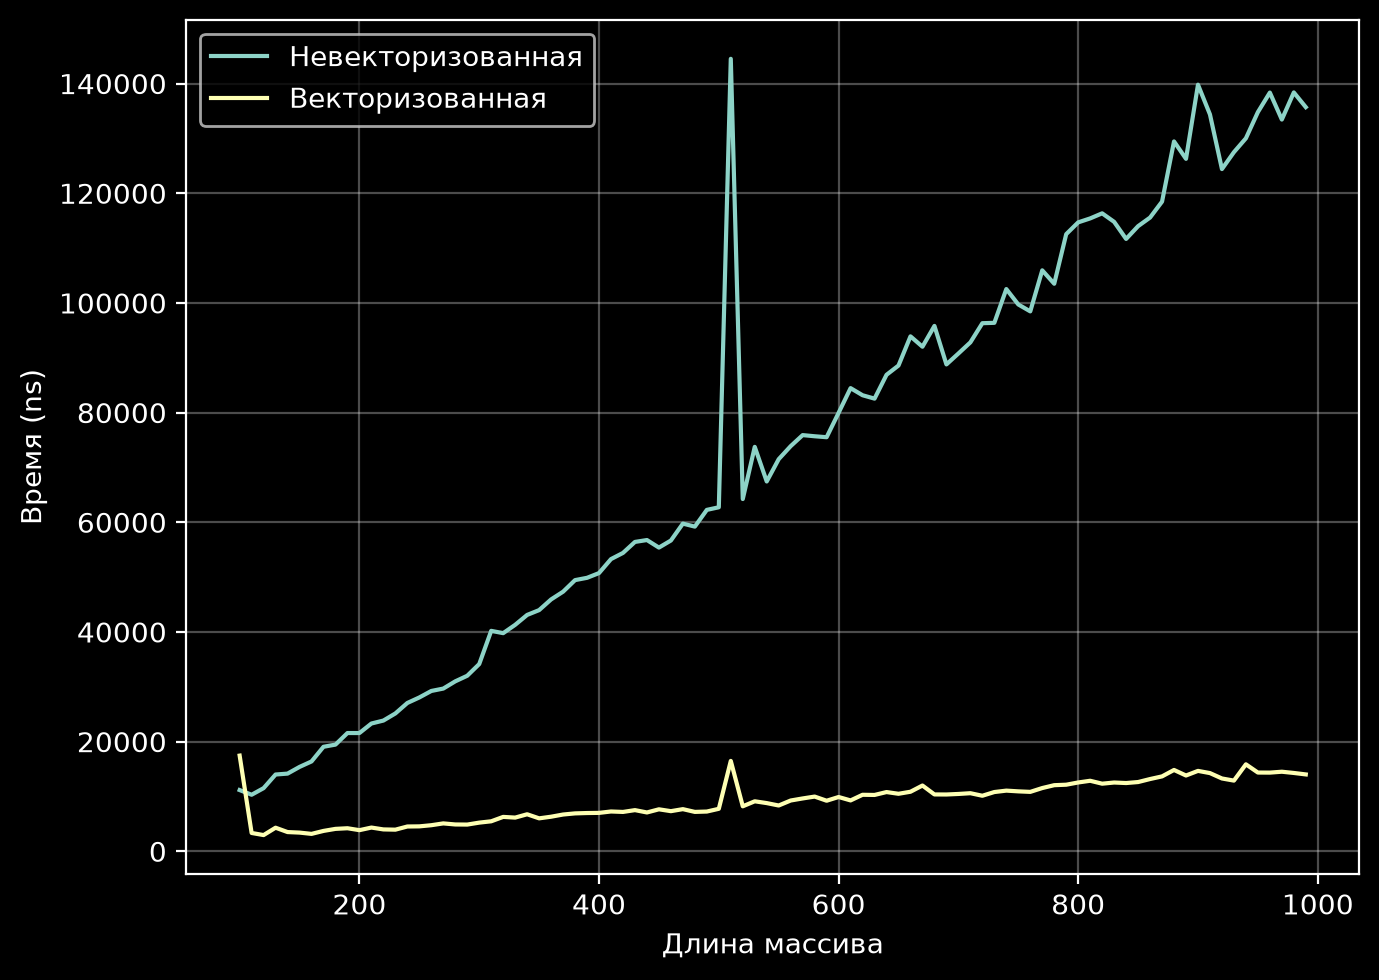

In [ ]:
reload_solution_modules()

def task2plot():
    data_size = np.arange(100, 1000, 10)
    tnv, tv = [], []
    for sz in data_size:
        sh = np.arange(sz)
        random.shuffle(sh)
        x = np.arange(sz)
        y = x + 1
        lx, ly, lsh = list(x), list(y), list(sh)
        time_non_vectorized = time.perf_counter_ns()
        res11 = functions.are_multisets_equal(lx, lsh)
        res12 = functions.are_multisets_equal(ly, lsh)
        tnv.append((time.perf_counter_ns() - time_non_vectorized) / 2)
        time_vectorized = time.perf_counter_ns()
        res21 = functions_vectorized.are_multisets_equal(x, sh)
        res22 = functions_vectorized.are_multisets_equal(y, sh)
        tv.append((time.perf_counter_ns() - time_vectorized) / 2)
        assert res11 == res21 and res12 == res22

    figure, axis_good = plt.subplots(1, 1, figsize=(7, 5))

    axis_good.plot(data_size, tnv, label="Невекторизованная")
    axis_good.plot(data_size, tv, label="Векторизованная")
    axis_good.set_xlabel("Длина массива")
    axis_good.set_ylabel("Время (ns)")
    axis_good.grid(True, alpha=0.3)
    axis_good.legend()

    figure.tight_layout()
    plt.show()

task2plot()

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

In [ ]:
reload_solution_modules()

def task3plot():
    data_size = np.arange(100, 100000, 1000)
    tnv, tv = [], []
    for sz in data_size:
        sh = np.arange(sz)
        random.shuffle(sh)
        lsh = list(sh)
        time_non_vectorized = time.perf_counter_ns()
        res11 = functions.max_after_zero(lsh)
        res12 = functions.max_after_zero(lsh)
        tnv.append((time.perf_counter_ns() - time_non_vectorized) / 2)
        time_vectorized = time.perf_counter_ns()
        res21 = functions_vectorized.max_after_zero(sh)
        res22 = functions_vectorized.max_after_zero(sh)
        tv.append((time.perf_counter_ns() - time_vectorized) / 2)
        assert res11 == res21 and res12 == res22

    figure, axis_good = plt.subplots(1, 1, figsize=(7, 5))

    axis_good.plot(data_size, tnv, label="Невекторизованная")
    axis_good.plot(data_size, tv, label="Векторизованная")
    axis_good.set_xlabel("Длина массива")
    axis_good.set_ylabel("Время (ns)")
    axis_good.grid(True, alpha=0.3)
    axis_good.legend()

    figure.tight_layout()
    plt.show()

task3plot()

ValueError: zero-size array to reduction operation maximum which has no identity

* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.

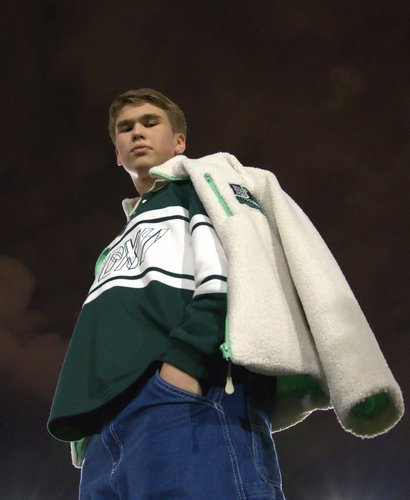

In [ ]:
from PIL import Image
kar = Image.open("/home/gemefoll/Downloads/828145703.jpeg")
img = np.asarray(kar.convert("RGB"))
kar

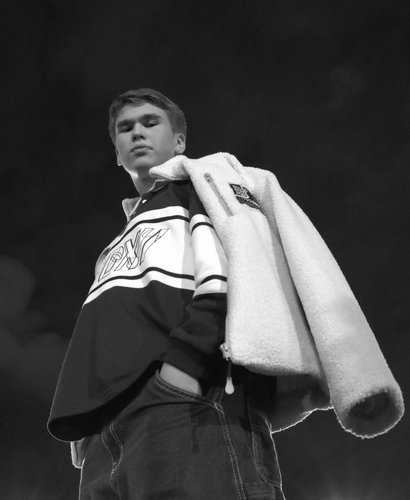

In [ ]:
reload_solution_modules()

Image.fromarray(functions_vectorized.convert_image(img, np.array([0.299, 0.587, 0.114])).round().astype(np.uint8))

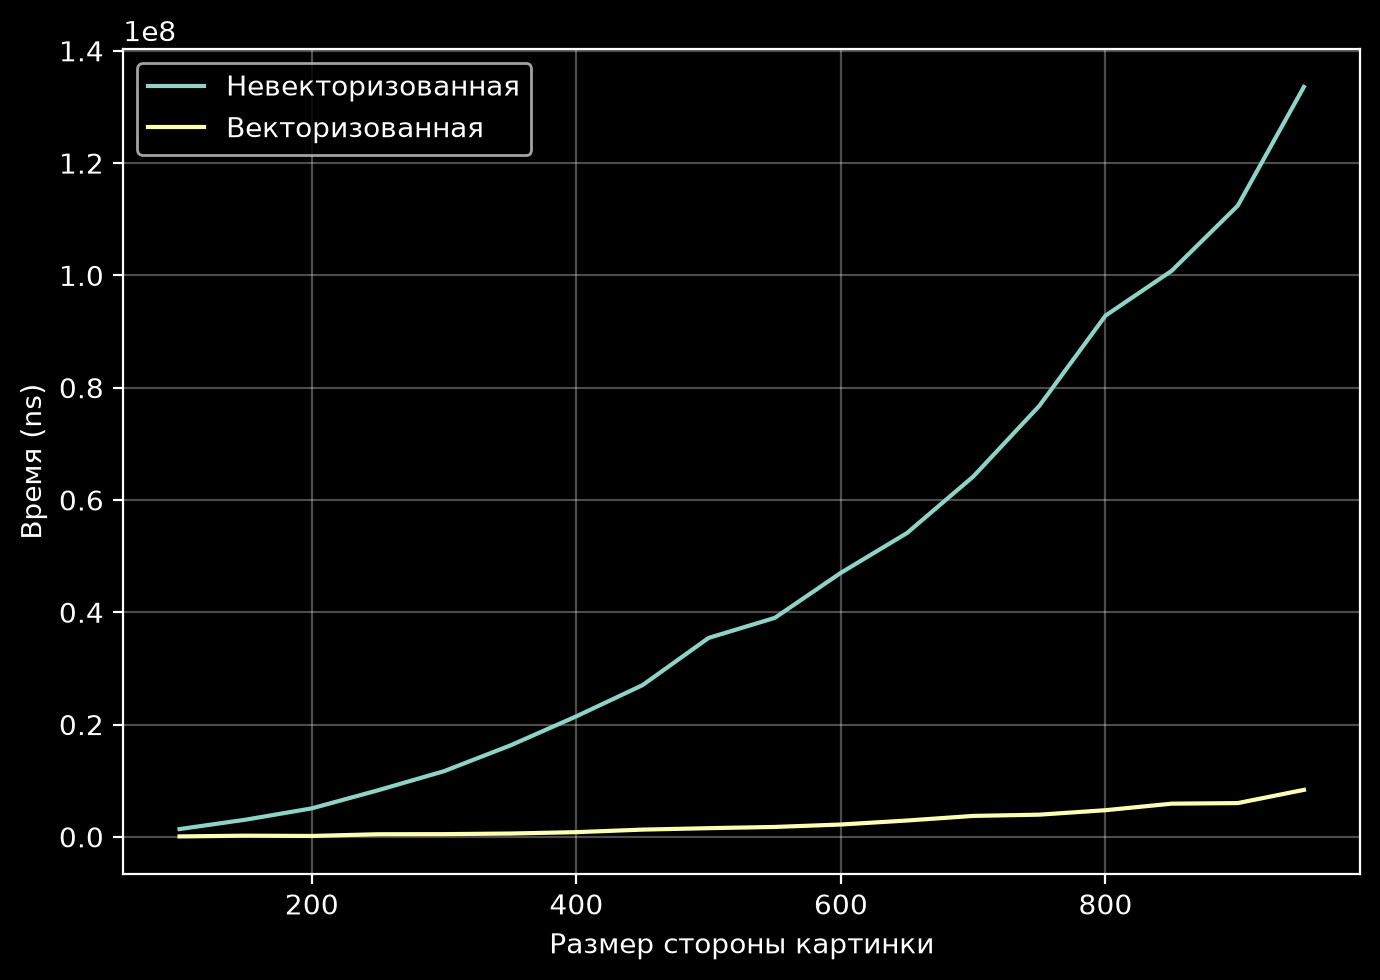

In [ ]:
reload_solution_modules()

def softmax(x, axis):
    ex = np.exp(x)
    return ex / np.sum(ex, axis=axis, keepdims=True)

def task4plot():
    data_size = np.arange(100, 1000, 50)
    tnv, tv = [], []
    for sz in data_size:
        sh = np.arange(sz)
        random.shuffle(sh)
        img1 = (
            (
                softmax(np.exp(np.random.normal(0, 1, (sz, sz, 3))), -1)
                * 255
            )
            .round()
            .astype(np.uint8)
        )
        img2 = np.random.randint(0, 255, (sz, sz, 3))
        coef1 = softmax(np.exp(np.random.normal(0, 1, (3))), -1)
        coef2 = softmax(np.exp(np.random.normal(0, 1, (3))), -1)
        limg1 = img1.tolist()
        limg2 = img2.tolist()
        lcoef1 = coef1.tolist()
        lcoef2 = coef2.tolist()
        time_non_vectorized = time.perf_counter_ns()
        res11 = functions.convert_image(limg1, lcoef1)
        res12 = functions.convert_image(limg2, lcoef2)
        tnv.append((time.perf_counter_ns() - time_non_vectorized) / 2)
        time_vectorized = time.perf_counter_ns()
        res21 = functions_vectorized.convert_image(img1, coef1)
        res22 = functions_vectorized.convert_image(img2, coef2)
        tv.append((time.perf_counter_ns() - time_vectorized) / 2)
        assert res11 == res21.tolist() and res12 == res22.tolist()

    figure, axis_good = plt.subplots(1, 1, figsize=(7, 5))

    axis_good.plot(data_size, tnv, label="Невекторизованная")
    axis_good.plot(data_size, tv, label="Векторизованная")
    axis_good.set_xlabel("Размер стороны картинки")
    axis_good.set_ylabel("Время (ns)")
    axis_good.grid(True, alpha=0.3)
    axis_good.legend()

    figure.tight_layout()
    plt.show()

task4plot()

* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

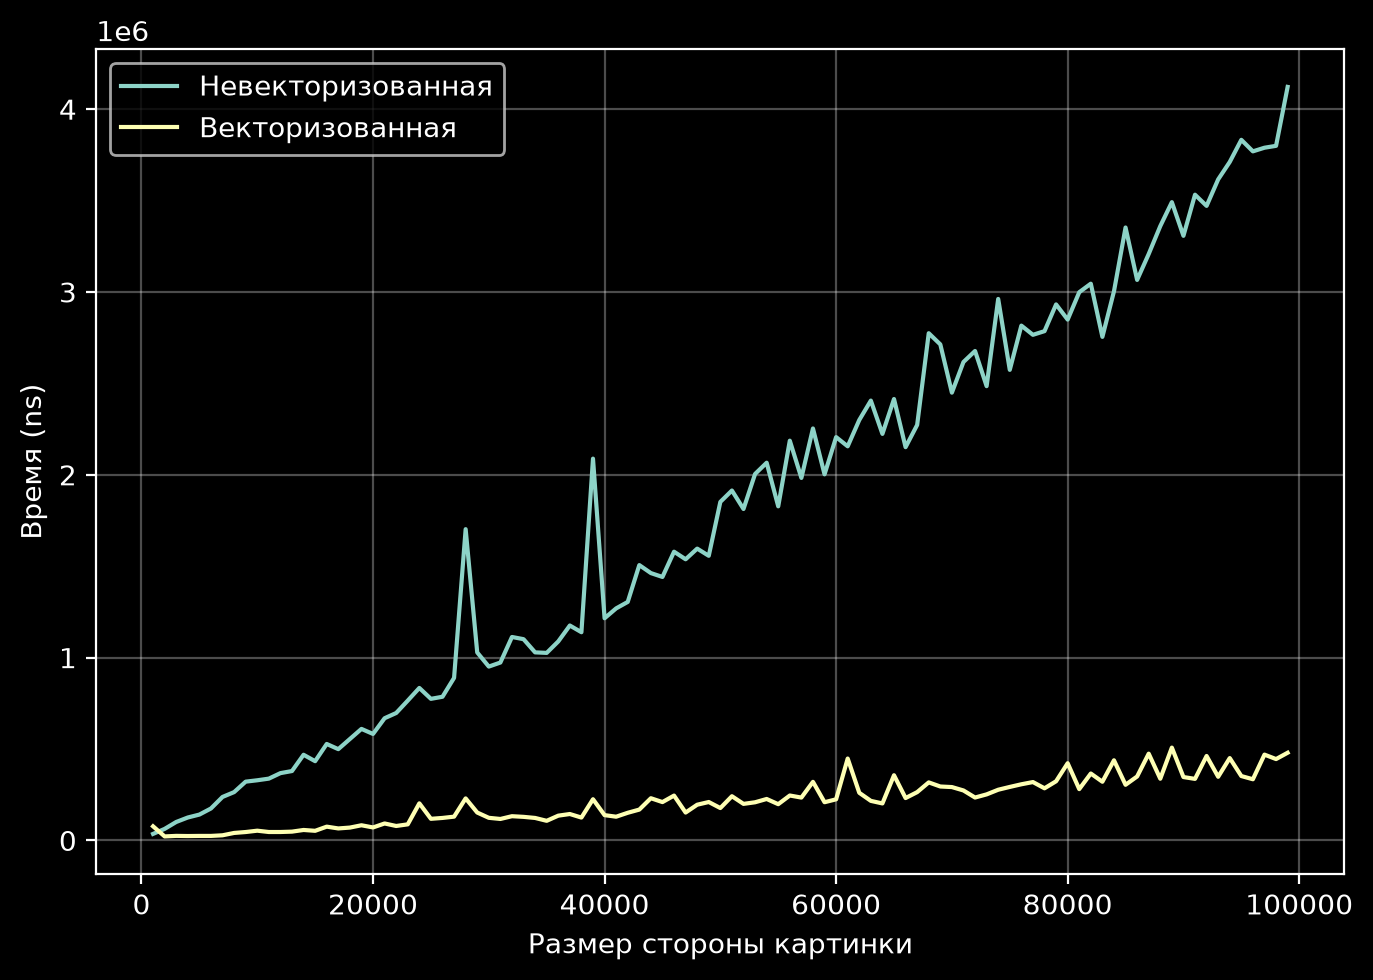

In [ ]:
reload_solution_modules()

def task5plot():
    data_size = np.arange(1000, 100000, 1000)
    tnv, tv = [], []
    for sz in data_size:
        sh = np.arange(sz)
        for i in range(sz):
            sh[i] = random.randrange(sz)
        lsh = sh.tolist()
        time_non_vectorized = time.perf_counter_ns()
        res11 = functions.run_length_encoding(lsh)
        res12 = functions.run_length_encoding(lsh)
        tnv.append((time.perf_counter_ns() - time_non_vectorized) / 2)
        time_vectorized = time.perf_counter_ns()
        res21 = functions_vectorized.run_length_encoding(sh)
        res22 = functions_vectorized.run_length_encoding(sh)
        tv.append((time.perf_counter_ns() - time_vectorized) / 2)
        # assert res11 == res21.tolist() and res12 == res22.tolist()

    figure, axis_good = plt.subplots(1, 1, figsize=(7, 5))

    axis_good.plot(data_size, tnv, label="Невекторизованная")
    axis_good.plot(data_size, tv, label="Векторизованная")
    axis_good.set_xlabel("Размер стороны картинки")
    axis_good.set_ylabel("Время (ns)")
    axis_good.grid(True, alpha=0.3)
    axis_good.legend()

    figure.tight_layout()
    plt.show()

task5plot()

* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

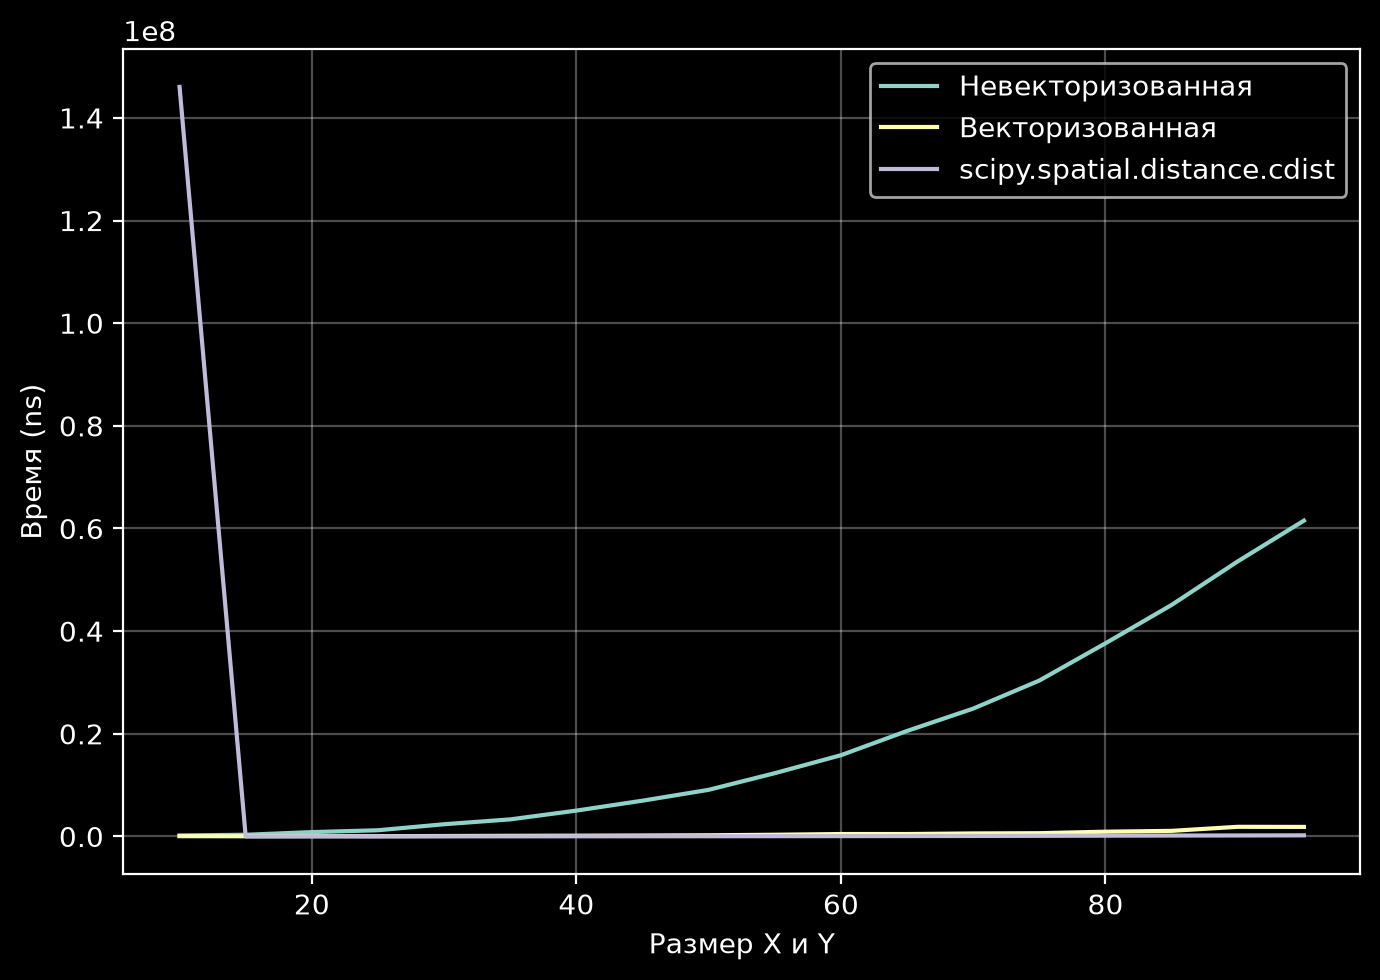

In [ ]:
reload_solution_modules()

import scipy

def task6plot():
    data_size = np.arange(10, 100, 5)
    tnv, tv, ts = [], [], []
    for sz in data_size:
        sh = np.arange(sz)
        random.shuffle(sh)
        X = np.random.normal(0, 1, (sz, sz))
        Y = np.random.normal(0, 1, (sz, sz))
        lx, ly = X.tolist(), Y.tolist()
        time_non_vectorized = time.perf_counter_ns()
        res11 = functions.pairwise_distance(lx, ly)
        res12 = functions.pairwise_distance(lx, ly)
        tnv.append((time.perf_counter_ns() - time_non_vectorized) / 2)
        time_vectorized = time.perf_counter_ns()
        res21 = functions_vectorized.pairwise_distance(X, Y)
        res22 = functions_vectorized.pairwise_distance(X, Y)
        tv.append((time.perf_counter_ns() - time_vectorized) / 2)
        time_standart = time.perf_counter_ns()
        res21 = scipy.spatial.distance.cdist(X, Y)
        res22 = scipy.spatial.distance.cdist(X, Y)
        ts.append((time.perf_counter_ns() - time_standart) / 2)
        # assert res11 == res21.tolist() and res12 == res22.tolist() Разная погрешность

    figure, axis_good = plt.subplots(1, 1, figsize=(7, 5))

    axis_good.plot(data_size, tnv, label="Невекторизованная")
    axis_good.plot(data_size, tv, label="Векторизованная")
    axis_good.plot(data_size, ts, label="scipy.spatial.distance.cdist")
    axis_good.set_xlabel("Размер X и Y")
    axis_good.set_ylabel("Время (ns)")
    axis_good.grid(True, alpha=0.3)
    axis_good.legend()

    figure.tight_layout()
    plt.show()

task6plot()

### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

# 📜 Отчет о Markdown-форматировании (Тестовый отчет)

Это краткий, но (как указано в задании) *почти бессмысленный* отчет, созданный с целью демонстрации нескольких вариантов разметки Markdown.

## Основные принципы

При использовании Markdown важно помнить, что синтаксис должен быть *последовательным* и *логичным*.

### Виды форматирования

Ниже приведены примеры использования различных элементов разметки, от простого выделения до структурных блоков.

1.  **Жирный текст (`**Два звездочки**`):** Используется для выделения *ключевых терминов* (например, **важность**).
2.  **Курсив (`*Одна звездочка*`):** Идеально подходит для упоминания *примечаний* или *исследований*.
3.  **Инлайн-код:** Этот блок используется для имитации *фрагментов кода* или команд, например: `mo.md(...)`.
4.  **Блоки кода:** Для демонстрации более длинных блоков, таких как:
    ```python
    for i in range(3):
        print(3)
    ```
5.  **Цитата:** Используется для выделения цитируемого материала, который может быть *отстранен от основного текста*.

> 💡 **Совет:** Используйте правильное сочетание элементов для повышения читаемости и *структуры* документа.

---

### Заключение

Написание этого отчета позволило продемонстрировать:

*   Использование заголовков (`#` и `##`).
*   Жирное и курсивное выделение.
*   Блоки кода и встроенный код.
*   Цитаты (`>`).
*   Горизонтальную линию (`---`).